# Прогнозирование сумм платежей с помощью catboost (+ SARIMAX)

Прогнозируем суммы платежей в различных формах - суммы платежей суммарно на следующие день/неделю/месяц, также с группировкой по различным описательным признакам (фонды, провайдеры платежей, тип подписки, категории платежей).

На **текущем этапе** данные подготовлены для прогнозирования сумм исходя из описательных признаков c учетом временной составляющей с применением нейросети LSTM.

<a id='К-содержанию'></a>
**Содержание проекта** \
[Загрузка и предобработка данных](#Загрузка-и-предобработка-данных)\
[Подготовка данных, агрегирование и генерация доппризнаков для прогнозирования сумм платежей](#Подготовка-данных,-агрегирование-и-генерация-доппризнаков-для-прогнозирования-сумм-платежей)\
[Построение и обучение LSTM](#Построение-и-обучение-LSTM)\
[Тестирование модели с визуализацией прогноза](#Тестирование-модели-с-визуализацией-прогноза)


In [1]:
%%capture
!pip install torch

In [2]:
#импортируем библиотеки перед началом проекта одним блоком
import os
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# загружаем класс pipeline и классы дя подготовки данных и запуска пайплайна
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from tqdm import notebook
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# загружаем нужные модели и метрики
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer


# загружаем библиотеки для Pytorch и предобученных моделей
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [3]:
# вынесем блок с настройками и функциями

# зададим стандарт датафрейма перед загрузкой
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('future.no_silent_downcasting', True)

# устанавливаем фиксированное значение для всех случайных библиотек
RANDOM_STATE = 42

def seed_all(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
seed_all(RANDOM_STATE)

def smape(y_true, y_pred):
    return 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

# cоздаём метрику smape
smape_scorer = make_scorer(smape, greater_is_better=False)

<a id='Загрузка-и-предобработка-данных'></a> 
## Загрузка и предобработка данных
[К содержанию](#К-содержанию)

In [4]:
# импортируем тренировочные данные
pth1 = 'data.csv'

if os.path.exists(pth1):
    data = pd.read_csv(pth1)
else:
    print('Something is wrong')

data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360258 entries, 0 to 360257
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   fund_id     360258 non-null  int64  
 1   full_sum    360258 non-null  float64
 2   date        360258 non-null  int64  
 3   provider    360258 non-null  int64  
 4   signup      360258 non-null  int64  
 5   category_1  360258 non-null  int64  
 6   category_2  360258 non-null  int64  
 7   category_3  360258 non-null  int64  
 8   category_4  360258 non-null  int64  
 9   category_5  360258 non-null  int64  
 10  category_6  360258 non-null  int64  
 11  category_7  360258 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 33.0 MB


,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7
0,44,500.00,1508393717,4,0,0,0,0,0,0,0,0
1,88,200.00,1508399528,4,0,0,0,0,0,0,0,0
2,1,100.00,1508400025,4,0,0,0,0,0,0,0,0
3,1,100.00,1508400043,4,0,0,0,0,0,0,0,0
4,1,20.00,1508400088,4,0,0,0,0,0,0,0,0


In [5]:
# посмотрим распределение меток по категориям
cat_columns = ['category_1', 'category_2', 'category_3', 'category_4', 'category_5', 'category_6', 'category_7']

data['cat_columns_sum'] = data[cat_columns].sum(axis=1)
display(data['cat_columns_sum'].value_counts())

data = data.drop(['cat_columns_sum'],axis=1)

cat_columns_sum
0    321861
1     21656
2     10219
3      6522
Name: count, dtype: int64

In [6]:
# проверим дубликаты
print('Количество дубликатов: ', data.duplicated().sum().sum())

# проверим пропуски
print('Количество пропусков: ', data.isna().sum().sum())

# уберем дубликаты и пропуски
data = data.drop_duplicates()
data = data.dropna()

Количество дубликатов:  2989
Количество пропусков:  0


In [7]:
# исключаем мегавыбросы (платежи более порога TRESHOLD_CONST) 
# для более адекватного обучения модели 

TRESHOLD_CONST = 0.95

threshold = data['full_sum'].quantile(TRESHOLD_CONST)
data = data[data['full_sum']<=threshold]

Выловили порядка 3 тысяч дубликатов, что с одной стороны маловероятно - одинаковые платежи в одну и ту же секунду, но, возможно, банк обработал платежи одним пакетом, с точки зрения обучения дубликаты не несут дополнительной информации, поэтому их удалили.  
Выбросы на суммы платежей более порога 95%-перцентиля рублей также исключили.


In [8]:
# по датам добавим столбец в наглядном формате datetime
data['datetime'] = pd.to_datetime(data['date'], unit='s')
data = data.drop('date', axis=1)

data.head() 

,fund_id,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
0,44,500.00,4,0,0,0,0,0,0,0,0,2017-10-19 06:15:17
1,88,200.00,4,0,0,0,0,0,0,0,0,2017-10-19 07:52:08
2,1,100.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:00:25
3,1,100.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:00:43
4,1,20.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:01:28


<a id='Подготовка-данных,-агрегирование-и-генерация-доппризнаков-для-прогнозирования-сумм-платежей'></a> 
## Подготовка данных, агрегирование и генерация доппризнаков для прогнозирования сумм платежей
[К содержанию](#К-содержанию)

In [9]:
# выберем фонд
data_fund = data[data['fund_id']==136].copy() #136

data_fund.info()
data_fund.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3924 entries, 527 to 360131
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fund_id     3924 non-null   int64         
 1   full_sum    3924 non-null   float64       
 2   provider    3924 non-null   int64         
 3   signup      3924 non-null   int64         
 4   category_1  3924 non-null   int64         
 5   category_2  3924 non-null   int64         
 6   category_3  3924 non-null   int64         
 7   category_4  3924 non-null   int64         
 8   category_5  3924 non-null   int64         
 9   category_6  3924 non-null   int64         
 10  category_7  3924 non-null   int64         
 11  datetime    3924 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 398.5 KB


,fund_id,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
527,136,100.00,5,1,0,0,1,0,0,0,0,2017-10-20 09:47:44
708,136,200.00,1,1,0,0,1,0,0,0,0,2017-10-20 14:40:08
15185,136,200.00,1,1,0,0,1,0,0,0,0,2017-11-02 14:19:13
15535,136,400.00,1,0,0,0,1,0,0,0,0,2017-11-02 22:45:43
16267,136,1000.00,1,0,0,0,1,0,0,0,0,2017-11-03 17:35:34


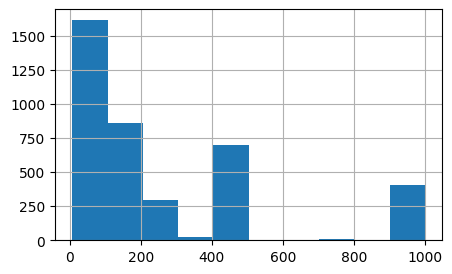

In [10]:
data_fund['full_sum'].hist(bins=10,figsize=(5, 3));

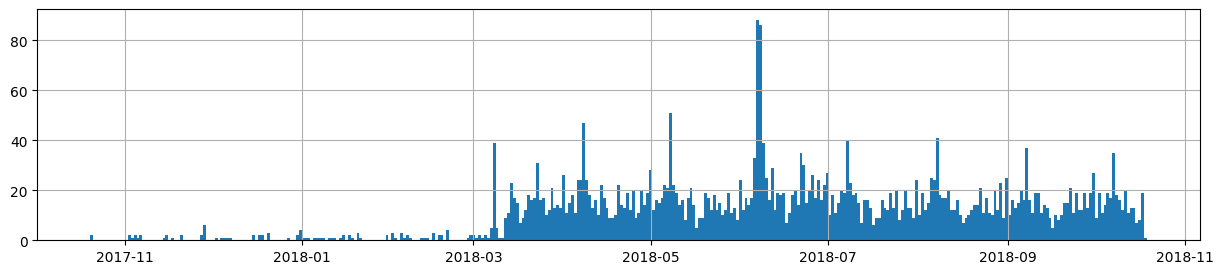

In [11]:
data_fund['datetime'].dt.date.hist(bins=365, figsize=(15, 3));

In [12]:
data_fund = data_fund.drop('fund_id', axis=1)
#data_fund = data_fund.drop('provider', axis=1)
#data_fund = data_fund.drop(['category_1', 'category_2','category_3', 'category_4', 'category_5', 'category_6', 'category_7'], axis=1) # признаки с нулевым влиянием - исключаем

# проверяем монотонность и сортируем при необходимости
if not data_fund['datetime'].is_monotonic_increasing:
    data_fund = data_fund.sort_values('datetime')

data_fund.head(1)

,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
527,100.00,5,1,0,0,1,0,0,0,0,2017-10-20 09:47:44


In [13]:
# функция  агрегации и добавления признаков
def agg_add_features_data_fund(data, rolling_window=2):
        
        data = data.copy()
        
        # добавляем столбец с датой
        data['date'] = data['datetime'].dt.floor('D')  # сохраняем формат datetime64[ns]
        

        # перед агрегацией заполняем пропуски нулевыми строками
        date_range = pd.date_range(start=data['date'].min(), end=data['date'].max())
        data_full = pd.DataFrame({'date': date_range})
        # объединяем исходные данные с полным списком дат
        data = data_full.merge(data, on='date', how='left')
        # для datetime используем значение из date
        data['datetime'] = data['datetime'].fillna(data['date'])
        # остальные столбцы заполняем нулями
        numeric_columns = data.columns.difference(['date', 'datetime'])
        data[numeric_columns] = data[numeric_columns].fillna(0)
        

        # добавляем столбцы с днем недели и номером недели в месяце
        data['day_of_week'] = data['datetime'].dt.weekday.astype('str')
        #data['week_number'] = data_fund['datetime'].dt.isocalendar().week.astype('str')  # Номер недели
        data['week_number'] = data['datetime'].dt.day.sub(1).floordiv(7).add(1)

        
        # кодируем признак 'provider'
        enc = OneHotEncoder(drop='first', sparse_output=False)
        encoded_provider = enc.fit_transform(data[['provider']])
        # переводим в датафейм и объединяем с исходными данными
        encoded_df = pd.DataFrame(encoded_provider, columns=enc.get_feature_names_out(['provider']), index=data.index)
        data = pd.concat([data.drop(columns=['provider']), encoded_df], axis=1)
        

        # определяем список столбцов для агрегации (все, кроме группировочного и временных)
        columns_to_aggregate = data.columns.difference(['date','datetime','day_of_week', 'week_number'])

        # делаем агрегацию исходных данных
        aggregated_data = data.groupby('date')[columns_to_aggregate].sum()
        aggregated_data.index.name = None

        # генерируем доппризнаки
        added_features = data.groupby('date').agg(
        count_payments=('full_sum', 'count'),  # количество платежей
        avg_payment=('full_sum', 'mean'),  # средний размер платежа
        median_payment=('full_sum', 'median'),  # медианный платеж
        min_payment=('full_sum', 'min'),  # минимальный платеж
        max_payment=('full_sum', 'max'),  # максимальный платеж
        day_of_week=('day_of_week', 'first'),  # день недели
        week_number=('week_number', 'first')  # номер недели
        )
        added_features.index.name = None
        
        # добавим скользящее среднее по платежам за последние n дней (например, 7 дней), исключая текущий день
        added_features['rolling_avg_payment'] = (added_features['avg_payment'].shift(1)
                                                 .rolling(window=rolling_window, min_periods=1)
                                                 .mean()
                                                 )

        # добавляем лаги на 1-7 дней
        for lag in range(1, 8):
                added_features[f'lag_{lag}_full_sum'] = aggregated_data['full_sum'].shift(lag)

        # Объединяем aggregated_data и added_features по индексу
        final_data = aggregated_data.join(added_features, how='left')
        final_data = final_data.dropna()

        # корректируем счетчик платежей, т.к. выше добавляли пустые строки для заполнения пропущенных дат
        final_data['count_payments'] = final_data.apply(lambda x: 0 if x['full_sum'] == 0 else x['count_payments'], axis=1)

        return final_data

# преобразовываем датасет
final_data_fund = agg_add_features_data_fund(data_fund)

display(final_data_fund.shape,
        final_data_fund.head(2))



(358, 28)

,category_1,category_2,category_3,category_4,category_5,category_6,category_7,full_sum,provider_1.0,provider_3.0,provider_4.0,provider_5.0,signup,count_payments,avg_payment,median_payment,min_payment,max_payment,day_of_week,week_number,rolling_avg_payment,lag_1_full_sum,lag_2_full_sum,lag_3_full_sum,lag_4_full_sum,lag_5_full_sum,lag_6_full_sum,lag_7_full_sum
2017-10-27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,4,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,300.00
2017-10-28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,5,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


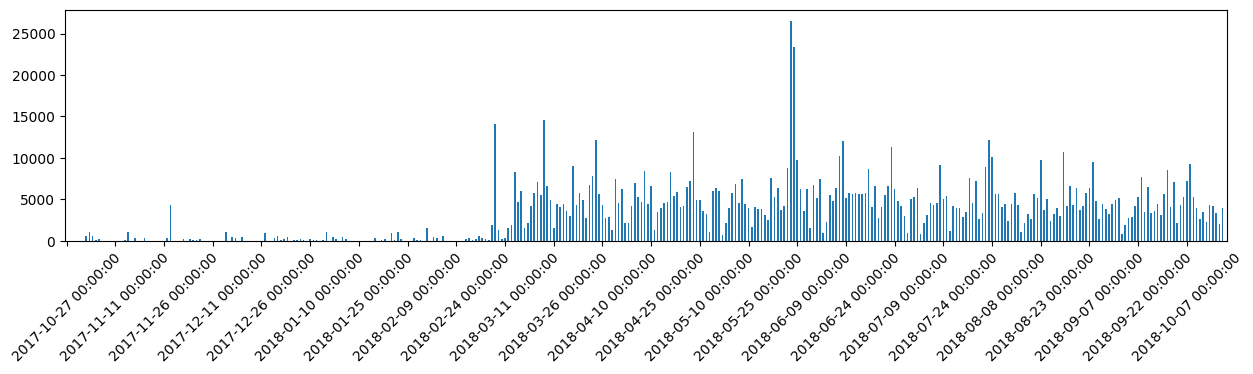

In [14]:
ax = final_data_fund['full_sum'].plot(kind='bar',figsize=(15, 3))

ax.set_xticks(ax.get_xticks()[::15])  #настраиваем подписи на оси x
plt.xticks(rotation=45)

plt.show()

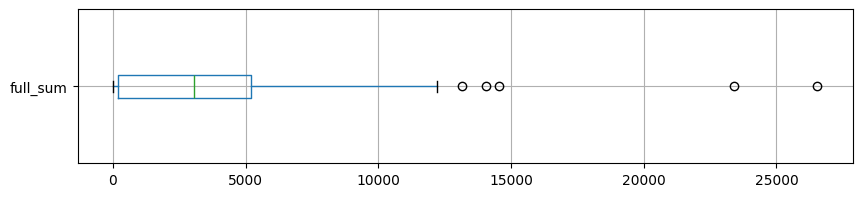

In [15]:
final_data_fund[['full_sum']].boxplot(figsize=(10, 2), vert=False);

In [16]:
# заменяем агрегированные дневные суммы из THRESHOLD_CONST перцентиля на медианное значение
threshold = final_data_fund['full_sum'].quantile(TRESHOLD_CONST)
print(threshold)
mean_full_sum = final_data_fund['full_sum'].median()
print(mean_full_sum)
final_data_fund.loc[final_data_fund['full_sum'] > threshold, 'full_sum'] = mean_full_sum

8954.5
3060.0


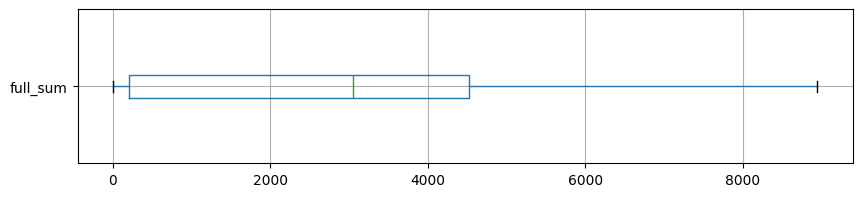

In [17]:
final_data_fund[['full_sum']].boxplot(figsize=(10, 2), vert=False);

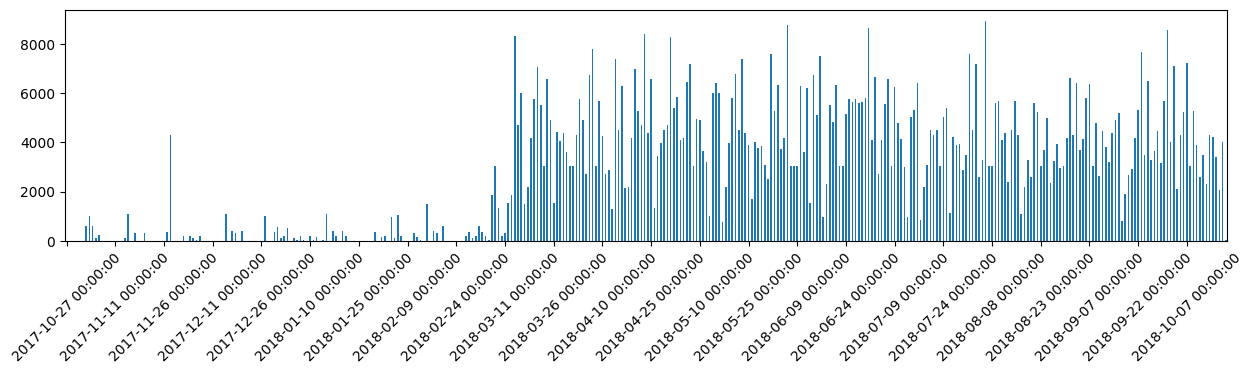

In [18]:
ax = final_data_fund['full_sum'].plot(kind='bar',figsize=(15, 3))

ax.set_xticks(ax.get_xticks()[::15])  # настрраиваем подписи по оси X
plt.xticks(rotation=45)

plt.show()

In [19]:
# сдвигаем целевую переменную на 1 назад, чтобы модель училась предсказывать по текущему значению признаков будущий день
final_data_fund_shifted = final_data_fund.copy()
final_data_fund_shifted['target_shifted'] = final_data_fund_shifted['full_sum'].shift(-1)

# убираем последнюю строку, так как она становится NaN из-за сдвига
final_data_fund_shifted = final_data_fund_shifted[:-1]

In [20]:
# определяем дату, начиная с которой данные будут отнесены к тестовой выборке
cutoff_date = final_data_fund_shifted.index.max() - pd.Timedelta(days=30) # последние 30 дней

# делим на train/test
final_train_data_fund = final_data_fund_shifted.loc[final_data_fund_shifted.index <= cutoff_date]
final_test_data_fund = final_data_fund_shifted.loc[final_data_fund_shifted.index > cutoff_date]

# проверяем размеры и даты
display(final_train_data_fund.shape, final_test_data_fund.shape)

print("Последняя тренировочная дата:", final_train_data_fund.index.max().date())
print("Первая тестовая дата:", final_test_data_fund.index.min().date())

(327, 29)

(30, 29)

Последняя тренировочная дата: 2018-09-18
Первая тестовая дата: 2018-09-19


In [21]:
# выделяем категоральные признаки
cat_features = ['day_of_week', 'week_number']

# формируем X_train и y_train
X_train = final_train_data_fund.drop(['full_sum', 'target_shifted'], axis=1)
y_train = final_train_data_fund['target_shifted']

# формируем X_test и y_test
X_test = final_test_data_fund.drop(['full_sum','target_shifted'], axis=1) 
y_test = final_test_data_fund['target_shifted']

In [22]:
# масштабируем числовые признаки
scaler_x = StandardScaler()
X_train_num_scaled = scaler_x.fit_transform(X_train.drop(columns=cat_features))
X_test_num_scaled = scaler_x.transform(X_test.drop(columns=cat_features))

# кодируем категориальные признаки
X_train_cat_encoded = pd.get_dummies(X_train[cat_features], dtype=float)
X_test_cat_encoded = pd.get_dummies(X_test[cat_features], dtype=float)

# выравниваем столбцы (если в тестовой выборке пропущены категории)
X_train_cat_encoded, X_test_cat_encoded = X_train_cat_encoded.align(X_test_cat_encoded, join='left', axis=1, fill_value=0)

# объединяем обратно
X_train_prepared = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_test_prepared = np.hstack([X_test_num_scaled, X_test_cat_encoded])

# масштабируем целевую переменную
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# преобразуем обратно в DataFrame для сохранения временных индексов
X_train_prepared = pd.DataFrame(
    X_train_prepared, 
    columns=list(X_train.drop(columns=cat_features).columns) + list(X_train_cat_encoded.columns),
    index=X_train.index)

X_test_prepared = pd.DataFrame(
    X_test_prepared, 
    columns=list(X_test.drop(columns=cat_features).columns) + list(X_test_cat_encoded.columns),
    index=X_test.index)

# преобразуем в Series(см.выше)
y_train_scaled = pd.Series(y_train_scaled.ravel(), name=y_train.name, index=y_train.index)
y_test_scaled = pd.Series(y_test_scaled.ravel(), name=y_test.name, index=y_test.index)

<a id='Построение-и-обучение-LSTM'></a> 
## Построение и обучение LSTM
[К содержанию](#К-содержанию)

In [23]:

# задаем шаги и количество разбиений временного ряда
time_steps = 7
n_splits = 15

# функция создания последовательностей для LSTM
def create_sequences(data, target, time_steps=1):
    X_seq, y_seq = [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i + time_steps])
        y_seq.append(target[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

# создаем последовательности
X_seq, y_seq = create_sequences(X_train_prepared, y_train_scaled, time_steps)

# делим данные последовательно для временного ряда
tss = TimeSeriesSplit(n_splits=n_splits)
rmse_scores_train = []
rmse_scores_test = []
smape_scores_train = []
smape_scores_test = []

for train_idx, test_idx in tss.split(X_seq):
    X_train_s, X_test_s = X_seq[train_idx], X_seq[test_idx]
    y_train_s, y_test_s = y_seq[train_idx], y_seq[test_idx]

    # конвертируем данные в тензоры для pytorch
    X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_s, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_s, dtype=torch.float32).view(-1, 1)

    # фомируем модель LSTM
    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, output_size):
            super(LSTMModel, self).__init__()
            self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
            self.dropout1 = nn.Dropout(0.2)
            #self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
            #self.dropout2 = nn.Dropout(0.2)
            self.fc1 = nn.Linear(hidden_size, 256)
            self.fc2 = nn.Linear(256, output_size)

        def forward(self, x):
            x, _ = self.lstm1(x)
            x = self.dropout1(x)
            #x, _ = self.lstm2(x)
            #x = self.dropout2(x)
            x = x[:, -1, :]
            x = self.fc1(x)
            x = torch.relu(x)
            x = self.fc2(x)
            return x

        
    # инициализация модели
    input_size = X_train_s.shape[2]
    hidden_size = 256
    output_size = 1
    model = LSTMModel(input_size, hidden_size, output_size)

    # задаем функцию потерь и оптимизатор
    #criterion = nn.MSELoss()
    criterion = nn.HuberLoss(delta=1.5)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

    # создаем ReduceLROnPlateau
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    # обучение модели
    num_epochs = 100
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_tensor)
        loss = criterion(output, y_train_tensor)
        loss.backward()
        optimizer.step()

        # вычисление RMSE и SMAPE на тренировочных данных
        if (epoch + 1) % 10 == 0:
            # разворачиваем масштабированные значения
            y_train_original = scaler_y.inverse_transform(y_train_tensor.detach().numpy().reshape(-1, 1))
            y_train_pred_original = scaler_y.inverse_transform(output.detach().numpy().reshape(-1, 1))

            # вычисление RMSE и SMAPE на развернутых данных
            train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
            train_smape = smape(y_train_original, y_train_pred_original)
            #print(f"Эпоха [{epoch + 1}/{num_epochs}], Потеря: {loss.item():.4f}, RMSE (train): {train_rmse:.4f}, SMAPE (train): {train_smape:.4f}")
    
    # Вызываем ReduceLROnPlateau
    scheduler.step(loss)  # передаем loss для отслеживания

    # вычисление RMSE и SMAPE на тестовых данных после обучения
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor)
        
        # разворачиваем масштабированные прогнозы
        y_test_original = scaler_y.inverse_transform(y_test_tensor.numpy().reshape(-1, 1))
        y_pred_original = scaler_y.inverse_transform(y_pred.numpy().reshape(-1, 1))

        # вычисление RMSE и SMAPE на развернутых данных
        test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        test_smape = smape(y_test_original, y_pred_original)
        #print(f"RMSE на тестовых данных: {test_rmse:.4f}, SMAPE на тестовых данных: {test_smape:.4f}  \n")

    rmse_scores_train.append(train_rmse)
    rmse_scores_test.append(test_rmse)
    smape_scores_train.append(train_smape)
    smape_scores_test.append(test_smape)


# выводим средние метрики RMSE и SMAPE для всех фолдов
print(f"Средний RMSE на тренировочных данных: {np.mean(rmse_scores_train):.4f}, Средний SMAPE на тренировочных данных: {np.mean(smape_scores_train):.4f}")
print(f"Средний RMSE на тестовых данных: {np.mean(rmse_scores_test):.4f}, Средний SMAPE на тестовых данных: {np.mean(smape_scores_test):.4f}")

/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_60367/1859968503.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_seq.append(target[i + time_steps])


Средний RMSE на тренировочных данных: 619.1313, Средний SMAPE на тренировочных данных: 119.2996
Средний RMSE на тестовых данных: 1588.6370, Средний SMAPE на тестовых данных: 85.2381


<a id='Тестирование-модели-с-визуализацией-прогноза'></a> 
## Тестирование модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [24]:
# формируем последовательности
X_seq_full, y_seq_full = create_sequences(X_train_prepared, y_train_scaled, time_steps)

# преобразуем в тензоры
X_full_tensor = torch.tensor(X_seq_full, dtype=torch.float32)
y_full_tensor = torch.tensor(y_seq_full, dtype=torch.float32).view(-1, 1)

# обучаем модель на всем тренировочном датасете
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_full_tensor)
    loss = criterion(output, y_full_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        y_full_original = scaler_y.inverse_transform(y_full_tensor.detach().numpy().reshape(-1, 1))
        y_full_pred_original = scaler_y.inverse_transform(output.detach().numpy().reshape(-1, 1))
        full_rmse = np.sqrt(mean_squared_error(y_full_original, y_full_pred_original))
        full_smape = smape(y_full_original, y_full_pred_original)
        print(f"Эпоха [{epoch + 1}/{num_epochs}], Потеря: {loss.item():.4f}, RMSE: {full_rmse:.4f}, SMAPE: {full_smape:.4f}")

/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_60367/1859968503.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_seq.append(target[i + time_steps])


Эпоха [10/100], Потеря: 0.0603, RMSE: 865.2666, SMAPE: 70.9881
Эпоха [20/100], Потеря: 0.0456, RMSE: 752.7480, SMAPE: 67.7501
Эпоха [30/100], Потеря: 0.0386, RMSE: 691.7272, SMAPE: 68.4934
Эпоха [40/100], Потеря: 0.0350, RMSE: 658.8918, SMAPE: 68.5992
Эпоха [50/100], Потеря: 0.0288, RMSE: 597.7787, SMAPE: 66.7049
Эпоха [60/100], Потеря: 0.0239, RMSE: 544.9103, SMAPE: 62.7607
Эпоха [70/100], Потеря: 0.0223, RMSE: 526.1508, SMAPE: 62.9583
Эпоха [80/100], Потеря: 0.0225, RMSE: 528.7351, SMAPE: 63.9120
Эпоха [90/100], Потеря: 0.0178, RMSE: 470.4208, SMAPE: 62.6232
Эпоха [100/100], Потеря: 0.0188, RMSE: 483.1406, SMAPE: 63.2264


In [25]:
# добавляем последние time_steps строк из тренировочного набора в тестовый
# (тк они нужны для запуска первого прогноза, чтобы не тратить на это тестовые данные)
X_test_full = pd.concat([X_train_prepared.tail(time_steps), X_test_prepared], axis=0)
y_test_full = pd.concat([y_train_scaled.tail(time_steps), y_test_scaled], axis=0)

# создаем последовательности для тестового набора
X_seq_test, y_seq_test = create_sequences(X_test_full.values, y_test_full.values, time_steps)

# преобразуем в тензоры
X_test_tensor = torch.tensor(X_seq_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_seq_test, dtype=torch.float32).view(-1, 1)

# делаем прогноз
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)

# разворачиваем масштабированные данные
y_test_original = scaler_y.inverse_transform(y_test_tensor.numpy()).flatten()
y_pred_original = scaler_y.inverse_transform(y_pred.numpy()).flatten()

# преобразуем y_test_original в Series с правильными временныеми индексами
y_test_original = pd.Series(y_test_original, index=y_test_full.index[-len(y_test_original):])

# считаем метрики
rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
smape_test = smape(y_test_original, y_pred_original)

print(f'Метрика RMSE на финальных тестовых данных: {rmse_test:.3f}')
print(f'Метрика SMAPE на финальных тестовых данных: {smape_test:.4f}')

Метрика RMSE на финальных тестовых данных: 1782.328
Метрика SMAPE на финальных тестовых данных: 36.2421


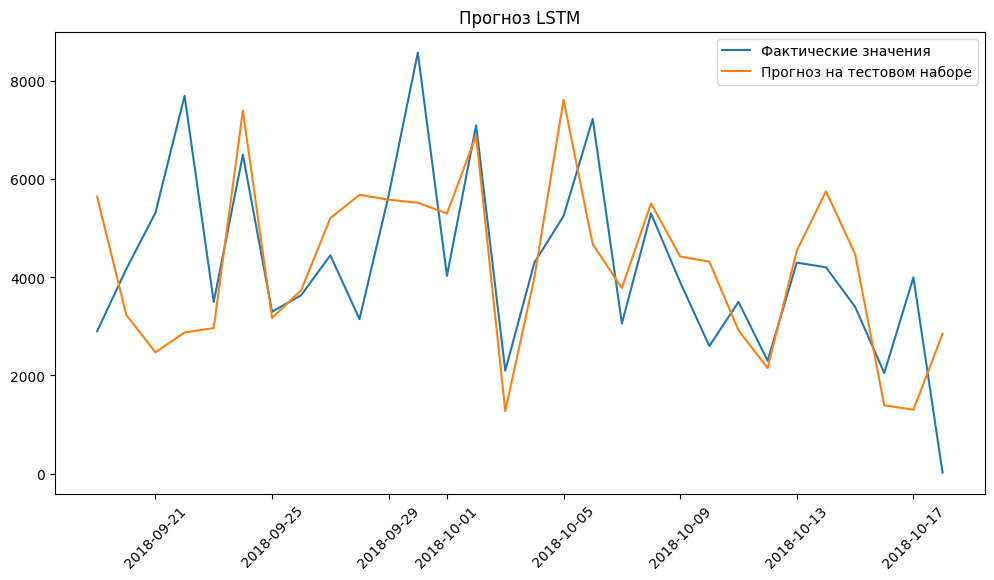

In [26]:
# смотрим на графике 
plt.figure(figsize=(12, 6))
plt.plot(y_test_original.index, y_test_original.values, label='Фактические значения')
plt.plot(y_test_original.index, y_pred_original, label='Прогноз на тестовом наборе')
plt.xticks(rotation=45)
plt.title('Прогноз LSTM')
plt.legend()
plt.show()


In [27]:
y_test_original.describe()

count     30.00
mean    4250.57
std     1854.26
min       20.00
25%     3187.50
50%     4015.00
75%     5287.50
max     8580.00
dtype: float64